# Drive Shaping Methods

A quantum program in the Rydberg analog model is defined as a time-dependent drive Hamiltonian that is imposed on the qubits (in addition to the interaction Hamiltonian). The drive shaping configuration part (the `drive_shaping` field of `SolverConfig`) defines how the drive parameters are constructed.

In this notebook, we show how to use different drive shaping methods:

- `HEURISTIC` *(Has no parameters to be customized).*
- `OPTIMIZED` *(Has seven parameters that can be customized).*

We choose the method when defining the `SolverConfig` configuration, with `drive_shaping_method = DriveType.(method)`

**Default SolverConfig parameters to run a quantum approach:**
- use_quantum: bool = False (*for using the drive shaping methods, we have to set it to `True`.*)
- backend: LocalEmulator | RemoteEmulator | QPU (by default, use a LocalEmulator based on qutip)
- device: Device = AnalogDeviceWithDMM() (also available: `AnalogDevice()`)
- embedding_method: str | EmbedderType | None = EmbedderType.GREEDY (also available: `BLADE`)
- drive_shaping_method: str | DriveType | None = DriveType.HEURISTIC (also available: `OPTIMIZED`)


In [ ]:
import torch

from qubosolver.qubo_instance import QUBOInstance
from qubosolver.config import SolverConfig, DriveShapingConfig
from qubosolver.qubo_types import DriveType
from qubosolver.solver import QuboSolver

import matplotlib.pyplot as plt
plt.rcParams["animation.html"] = "jshtml"

%matplotlib inline

** Create the <code>QUBOInstance</code> **

Here, we have a 3x3 QUBO matrix with negative diagonal and positive off-diagonal terms.

In [ ]:
coefficients = torch.tensor([[-1.0, 0.5, 0.2], [0.5, -2.0, 0.3], [0.2, 0.3, -3.0]])
instance = QUBOInstance(coefficients)

## Heuristic Drive Shaper

Default method


[HEURISTIC] num_shots=500
Solution object:
QUBOSolution(bitstrings=tensor([[1, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [1, 0, 0, 0],
        [0, 0, 0, 0]], dtype=torch.int32), costs=tensor([-9.5000, -7.5000, -7.5000, -7.0000, -6.0000,  0.0000]), counts=tensor([  1, 352, 119,  20,   5,   3]), probabilities=tensor([0.0020, 0.7040, 0.2380, 0.0400, 0.0100, 0.0060]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)
Best sampled cost: -9.5
Best sampled bitstring: [1, 0, 1, 0]

[HEURISTIC] num_shots=500
Solution object:
QUBOSolution(bitstrings=tensor([[1, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [1, 0, 0, 0],
        [1, 1, 1, 1],
        [0, 0, 0, 0]], dtype=torch.int32), costs=tensor([-9.5000, -7.5000, -7.5000, -7.0000, -6.0000, -4.0000,  0.0000]), counts=tensor([  1, 154,  18, 153, 172,   1,   1]), probabilities=tensor([0.0020, 0.3080, 0.0360, 0.3060, 0.3440, 0.0020, 0.0020]), solution_s

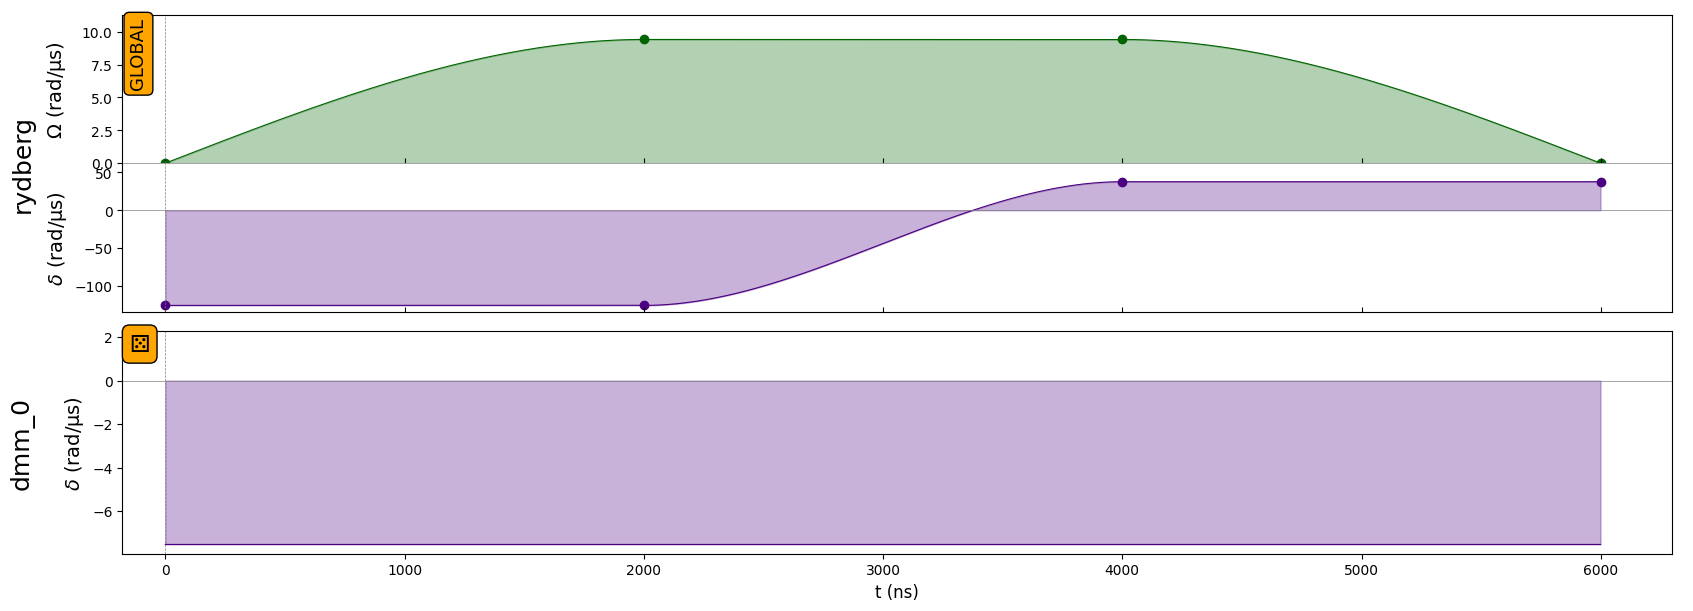

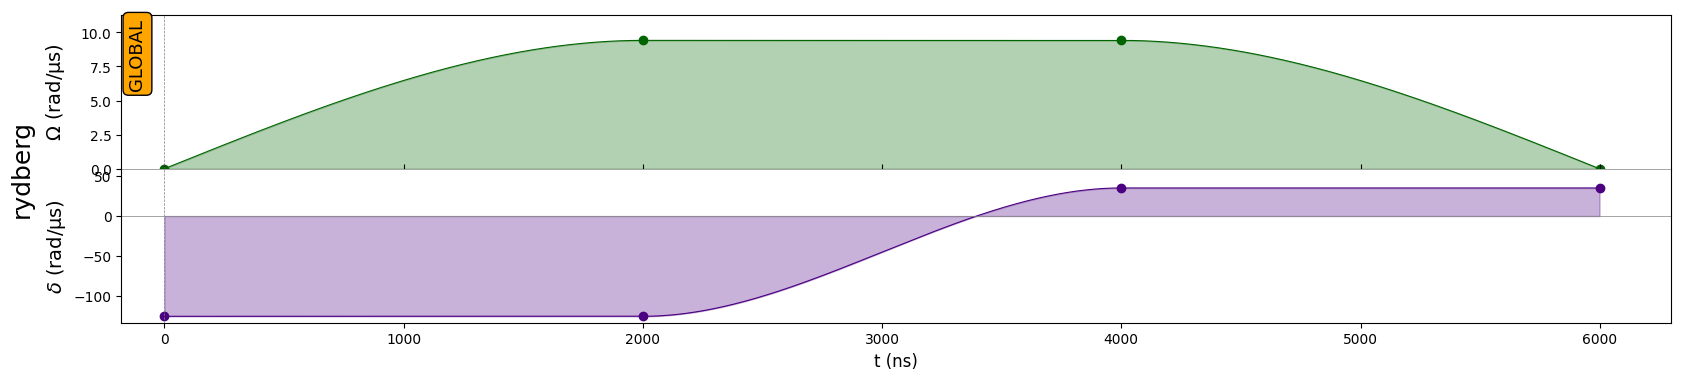

In [ ]:
import torch

from qubosolver.qubo_instance import QUBOInstance
from qubosolver.config import EmbeddingConfig, LocalEmulator

from pulser_simulation import QutipBackendV2


def best_from_solution(sol):
    # sol.costs: tensor([..]) ; sol.bitstrings: tensor([[..],..])
    if sol.costs is None or len(sol.costs) == 0:
        return None, None
    idx = int(torch.argmin(sol.costs).item())
    best_cost = float(sol.costs[idx].item())
    best_bitstring = sol.bitstrings[idx].tolist()
    return best_cost, best_bitstring


def run_one(method: DriveType, q: torch.Tensor, num_shots: int = 500, dmm: bool = True):
    instance = QUBOInstance(coefficients=q)

    embed_cfg = EmbeddingConfig(
        embedding_method="greedy",
        greedy_traps=6,
    )

    drive_cfg = DriveShapingConfig(
        drive_shaping_method=method,
        dmm=dmm,
    )

    backend = LocalEmulator(backend_type=QutipBackendV2, num_shots=num_shots)

    config = SolverConfig(
        use_quantum=True,
        embedding=embed_cfg,
        drive_shaping=drive_cfg,
        backend=backend,
    )

    solver = QuboSolver(instance, config)

    # solve (inclut exécution + mesure)
    sol = solver.solve()

    # afficher la séquence
    embedding = solver.embedding()
    drive = solver.drive(embedding)[0]
    solver.draw_sequence(drive, embedding)

    best_cost, best_bitstring = best_from_solution(sol)

    tag = "HEURISTIC"
    print("\n" + "=" * 80)
    print(f"[{tag}] num_shots={num_shots}")
    print("Solution object:")
    print(sol)
    print(f"Best sampled cost: {best_cost}")
    print(f"Best sampled bitstring: {best_bitstring}")

    return sol, best_cost, best_bitstring


if __name__ == "__main__":
    Q1 = torch.tensor([
        [-6.0,  2.0,  2.0,  2.0],
        [ 2.0, -7.5,  2.0,  2.0],
        [ 2.0,  2.0, -7.5,  2.0],
        [ 2.0,  2.0,  2.0, -7.0],
    ])

    sol_h_dmm, best_h_dmm, bs_h_dmm = run_one(DriveType.HEURISTIC, Q1, num_shots=500, dmm=True)
    sol_h_nodmm, best_h_nodmm, bs_h_nodmm = run_one(DriveType.HEURISTIC, Q1, num_shots=500, dmm=False)

    print("\n" + "#" * 80)
    print("COMPARISON (best sampled cost):")
    print(f"HEURISTIC (dmm=True) : {best_h_dmm}  bitstring={bs_h_dmm}")
    print(f"HEURISTIC (dmm=False): {best_h_nodmm}  bitstring={bs_h_nodmm}")

## Optimized Drive shaping 

#### Parameters to customize:

For the OPTIMIZED drive shaping, we have the following parameters:
- optimized_n_calls: Number of calls for the optimization process.
- optimized_re_execute_opt_drive: Whether to re-run the optimal drive sequence after optimization.
- optimized_initial_omega_parameters: Default initial omega parameters for the drive. Defaults to (1, 2, 1).
- optimized_initial_detuning_parameters: Default initial detuning parameters for the drive. Defaults to (-2, 0, 2).

#### Default configuration

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.OPTIMIZED),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[1, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0]], dtype=torch.int32), costs=tensor([-3.6000, -3.0000, -2.0000, -1.0000,  0.0000]), counts=tensor([  7, 857,   6, 125,   5], dtype=torch.int32), probabilities=tensor([0.0070, 0.8570, 0.0060, 0.1250, 0.0050]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing <code>optimized_n_calls</code>

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.OPTIMIZED, optimized_n_calls=13),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[1, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0]], dtype=torch.int32), costs=tensor([-3.6000, -3.0000, -2.0000, -1.0000,  0.0000]), counts=tensor([177, 107, 146,  19, 551], dtype=torch.int32), probabilities=tensor([0.1770, 0.1070, 0.1460, 0.0190, 0.5510]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing the initial parameters

Initial parameters of the optimization procedure can be changed as `optimized_initial_omega_parameters` and `optimized_initial_detuning_parameters`

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.OPTIMIZED, optimized_initial_omega_parameters=[0.5, 0.9, 0.5,], optimized_initial_detuning_parameters=[-0.9, 0.0, 0.5]),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[0, 1, 1],
        [1, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0]], dtype=torch.int32), costs=tensor([-4.4000, -3.6000, -3.0000, -2.0000, -1.0000,  0.0000]), counts=tensor([  1, 305, 349,   1, 343,   1], dtype=torch.int32), probabilities=tensor([0.0010, 0.3050, 0.3490, 0.0010, 0.3430, 0.0010]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing <code>optimized_re_execute_opt_drive</code>

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.OPTIMIZED, optimized_re_execute_opt_drive=True),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[0, 1, 1],
        [1, 0, 1],
        [0, 0, 0]], dtype=torch.int32), costs=tensor([-4.4000, -3.6000,  0.0000]), counts=tensor([  2,  18, 980]), probabilities=tensor([0.0020, 0.0180, 0.9800]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Adding custom functions

One can change the drive shaping method by incorporating custom functions for:
- Evaluating a candidate bitstring and QUBO via `optimized_custom_qubo_cost`
- Performing optimization with a different objective than the best cost via `optimized_custom_objective`
- Adding callback functions via `optimized_callback_objective`.

In [ ]:
from qubosolver.utils.qubo_eval import calculate_qubo_cost

# example of penalization
def penalized_qubo(bitstring: str, QUBO: torch.Tensor) -> float:
    return calculate_qubo_cost(bitstring, QUBO) + 2 * bitstring.count("0")

# example of saving intermediate results
opt_results = list()
def callback(d: dict) -> None:
    opt_results.append(d)

# example of using an average cost
def average_ojective(
    bitstrings: list,
    counts: list,
    probabilities: list,
    costs: list,
    best_cost: float,
    best_bitstring: str,
) -> float:
    return sum([p * c for p, c in zip(probabilities, costs)])

drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.OPTIMIZED, 
    optimized_re_execute_opt_drive=True,
    optimized_custom_qubo_cost=penalized_qubo, 
    optimized_callback_objective=callback,
    optimized_custom_objective = average_ojective,
)

config = SolverConfig(
    use_quantum=True, 
    drive_shaping=drive_shaping,
)

In [ ]:
solver = QuboSolver(instance, config)
solution = solver.solve()
len(opt_results), opt_results[-1]

(20,
 {'x': [0.8051578103612673,
   0.8368783460382281,
   0.7028792216975073,
   -0.8546360011220893,
   -0.3710044115873592,
   0.7358606666173104],
  'cost_eval': 1.003})

In [ ]:
solution

QUBOSolution(bitstrings=tensor([[0, 0, 1]], dtype=torch.int32), costs=tensor([-3.]), counts=tensor([1000]), probabilities=tensor([1.]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)